# `PerinuclearSignalDetector` in action

In this example, we apply `PerinuclearSignalDetector` from `coSMicQC` on an example dataset from the NF1 project.

The NF1 project example includes wells from a cell line that was contaminated with mycoplasma, which is reflected as abnormal perinuclear signal in the nuclear channel.
In the wet lab, these cells were detected as negative for mycoplasma.
We do not want to process contaminated cells, so we can use this methodology to confirm the contamination and the extent of it on the plate.

The result of this method is either a pass or fail.
If the data is clean, then the method stops at step 1 and says the data is ready for further downstream analysis.
If the data has abnormal perinuclear signal, this method will continue processing after step 1 to determine if the problem is for the whole plate or part of the plate.


In [1]:
import pandas as pd

from cosmicqc import PerinuclearSignalDetector

# set a path for the NF1 parquet-based dataset
data_path = (
    "../../../tests/data/cytotable/NF1_cellpainting_data/Plate_3_filtered.parquet"
)

In [2]:
# Load in the dataset
filtered_nf1_df = pd.read_parquet(data_path)

# Look over the data to check it is correct
print(filtered_nf1_df.shape)

(1355, 2321)


Running step 1...
Summary:

Check                    Result
-----------------------  --------
Texture skewed?          🔴
Nucleus shape variable?  🟢
Interpretation:
Abnormal perinuclear signal detected! 🚨
Anomalous texture around nuclei detected but nuclei segmentation not clearly impacted.
Proceeding to step 2...
Running step 2...
Summary:

Check                                                              Result
-----------------------------------------------------------------  --------
Texture skewed?                                                    🔴
Nucleus shape variable?                                            🟢
Whole plate has perinuclear signal due to abnormal texture?        🟢
Whole plate has perinuclear signal due to abnormal nucleus shape?  🟢
Interpretation:
Partial plate abnormal perinuclear signal in texture only. Proceed to step 3.
Running step 3...
Finding outlier cells with anomalous texture around the nucleus...
Number of outliers: 198 (14.61%)
Outliers Range:
Cyt

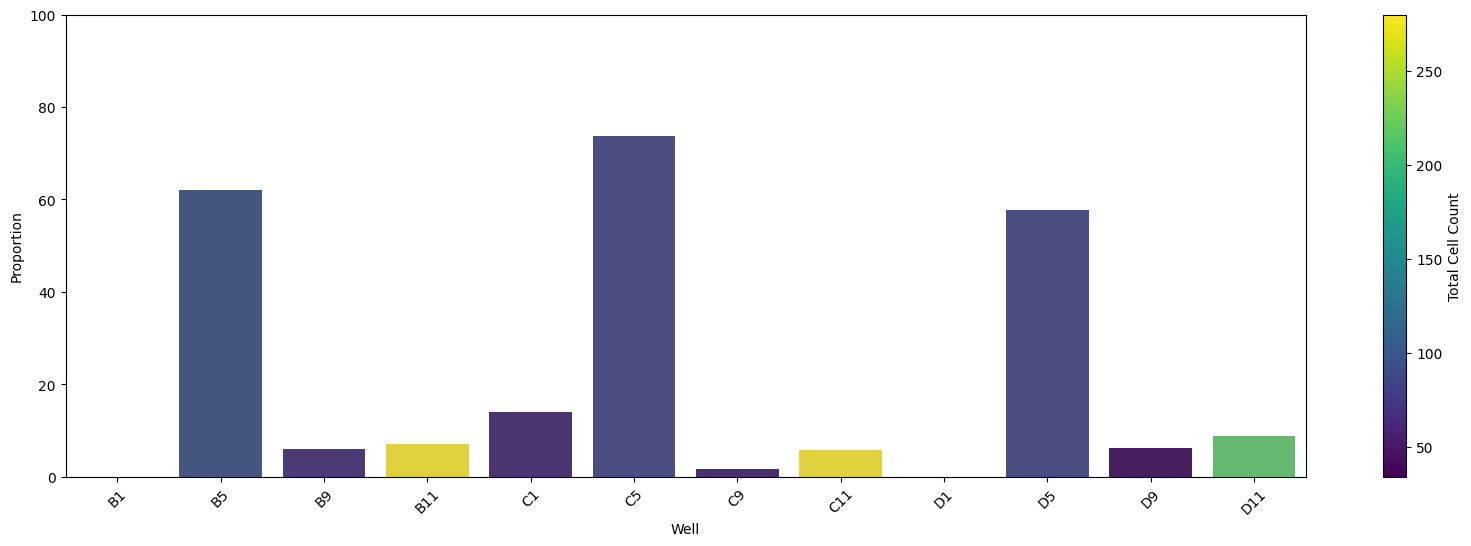


Number of wells in the top 25%: 3
Wells in the top 25% of highest outlier proportions:
B5, C5, D5


In [3]:
# Instantiate the PerinuclearSignalDetector class and run the contamination detection process
detector = PerinuclearSignalDetector(
    dataframe=filtered_nf1_df, nucleus_channel_naming="DAPI"
)
detector.run()

In this example, we can see that the detector has found anomalous texture surrounding the nucleus from this plate. This is a problem and could likely reflect abnormal perinuclear signal.

In step 2, based on the mean of the texture, it was found that this problem only impacts part of the plate.

In step 3, we found 3 wells that have high proportion of outlier single-cells with abnormal texture. This was concluded to be one cell line that had mycoplasma contamination on the plate, while the rest of the cell lines were fine.